# Notebook 1 — Visão Computacional: Fundamentos e Processamento Clássico

## Objetivo deste notebook

Entender a base da visão computacional:

1. imagem como matriz -- item matematico;
2. imagem RGB e tons de cinza;
3. histograma;
4. contraste;
5. filtros;
6. bordas -- zonas de transicao;
7. segmentação simples.

> A ideia é mostrar que o computador não “enxerga” a imagem como uma pessoa. Ele trabalha somente com números. Uso de vetores e matrizes.

## Bloco 0 — Preparação do ambiente

Importamos as bibliotecas para trabalho.

In [1]:
import sys
import subprocess
import importlib.util

def instalar_se_precisar(pacote, nome_import=None):
    nome_import = nome_import or pacote
    if importlib.util.find_spec(nome_import) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pacote])

instalar_se_precisar("opencv-python", "cv2")
instalar_se_precisar("scikit-image", "skimage")

import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = False

print("Ambiente pronto!")

Ambiente pronto!


## Bloco 1 — Imagem como matriz

Uma imagem em tons de cinza é uma matriz.
Existe uma notacao ou regra para cores e numeros:

- `0` representa preto.
- `255` representa branco.
- Valores intermediários representam tons de cinza.
- Uso de vetores e matrizes para representar imagens 2D e 3D.

[[  0   0   0   0   0]
 [  0 100 100 100   0]
 [  0 100 255 100   0]
 [  0 100 100 100   0]
 [  0   0   0   0   0]]


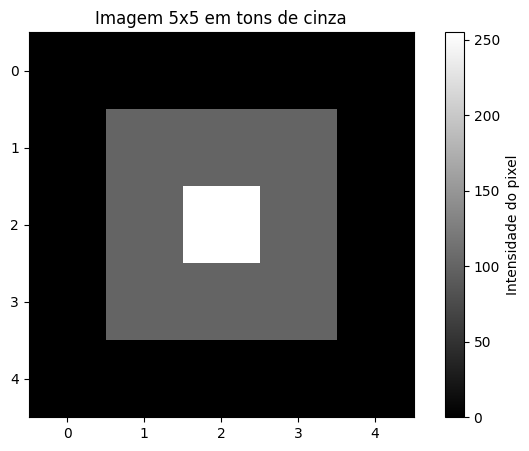

In [2]:
imagem_simples = np.array([
    [0,   0,   0,   0,   0],
    [0, 100, 100, 100, 0],
    [0, 100, 255, 100, 0],
    [0, 100, 100, 100, 0],
    [0,   0,   0,   0,   0]
], dtype=np.uint8)

print(imagem_simples)

plt.imshow(imagem_simples, cmap="gray", vmin=0, vmax=255)
plt.title("Imagem 5x5 em tons de cinza")
plt.colorbar(label="Intensidade do pixel")
plt.show()

## Bloco 2 — Imagem RGB -- uso de cores

Uma imagem colorida normalmente tem três canais:

- R: vermelho (RED);
- G: verde (GREEN);
- B: azul (BLUE).

Cada pixel (dimensao espacial) deixa de ter apenas um número e passa a ter três números.

Formato da imagem: (512, 512, 3)


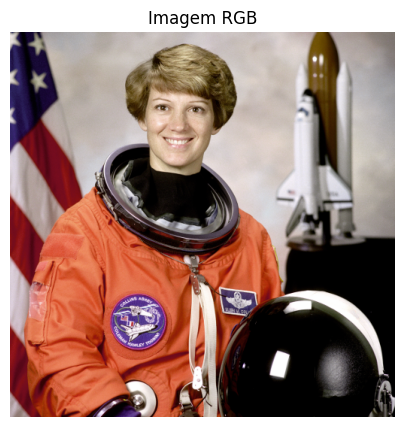

In [3]:
imagem_rgb = data.astronaut()

print("Formato da imagem:", imagem_rgb.shape)

plt.imshow(imagem_rgb)
plt.title("Imagem RGB")
plt.axis("off")
plt.show()

## Bloco 3 — Separando os canais ou grupos de dados sobre as cores

Aqui enxergamos a contribuição de cada canal da imagem.
Decomposicao de cada parcela ou grupo de cores especificas.

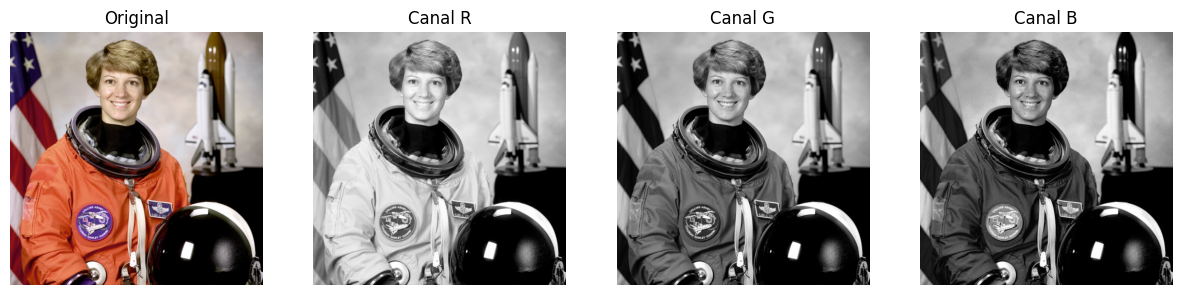

In [4]:
R = imagem_rgb[:, :, 0]
G = imagem_rgb[:, :, 1]
B = imagem_rgb[:, :, 2]

fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].imshow(imagem_rgb)
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(R, cmap="gray")
axs[1].set_title("Canal R")
axs[1].axis("off")

axs[2].imshow(G, cmap="gray")
axs[2].set_title("Canal G")
axs[2].axis("off")

axs[3].imshow(B, cmap="gray")
axs[3].set_title("Canal B")
axs[3].axis("off")

plt.show()

## Bloco 4 — Convertendo para tons de cinza

Muitos algoritmos clássicos usam imagem em tons de cinza porque isso reduz custo computacional.

RGB: (512, 512, 3)
Tons de cinza: (512, 512)


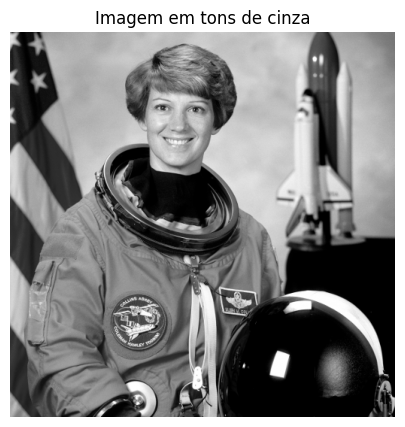

In [5]:
imagem_gray = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2GRAY)

print("RGB:", imagem_rgb.shape)
print("Tons de cinza:", imagem_gray.shape)

plt.imshow(imagem_gray, cmap="gray")
plt.title("Imagem em tons de cinza")
plt.axis("off")
plt.show()

## Bloco 5 — Histograma

O histograma quantifica cada parcela, mostrando quantos pixels existem em cada intensidade.

Ele ajuda a avaliar brilho e contraste.

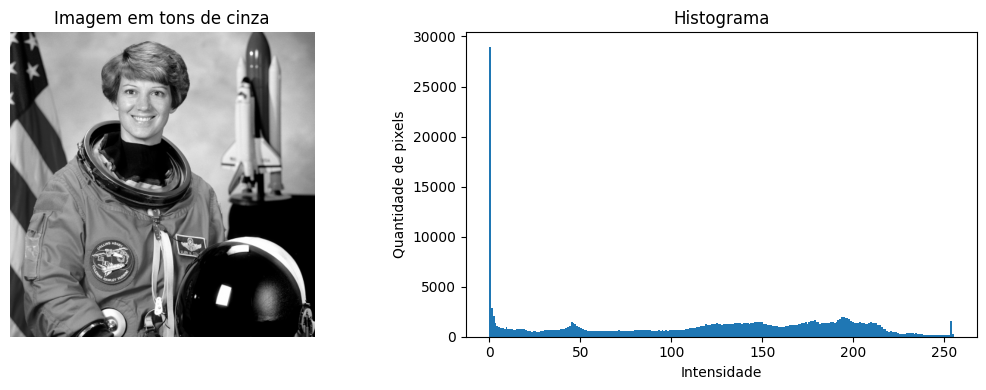

In [6]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.imshow(imagem_gray, cmap="gray")
plt.title("Imagem em tons de cinza")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(imagem_gray.ravel(), bins=256)
plt.title("Histograma")
plt.xlabel("Intensidade")
plt.ylabel("Quantidade de pixels")

plt.tight_layout()
plt.show()

## Bloco 6 — Equalização de histograma

A equalização tenta melhorar o contraste espalhando melhor as intensidades.

É um ajuste matematico nos elementos dos arrays, seja por multiplicacao ou soma de produtos.

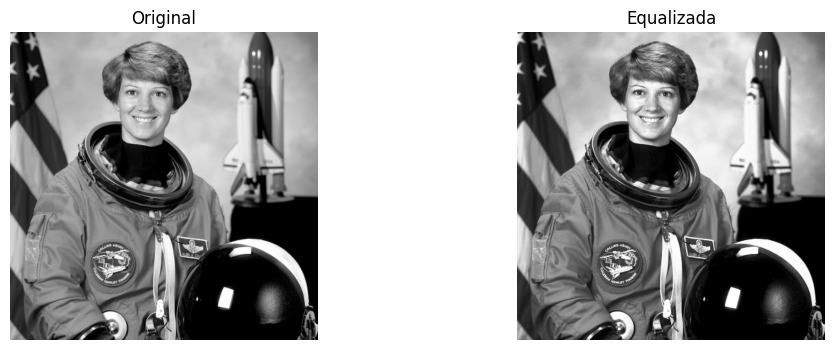

In [7]:
imagem_equalizada = cv2.equalizeHist(imagem_gray)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].imshow(imagem_gray, cmap="gray")
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(imagem_equalizada, cmap="gray")
axs[1].set_title("Equalizada")
axs[1].axis("off")

plt.show()

## Bloco 7 — Filtros: suavização e nitidez

Filtros alteram cada pixel considerando seus vizinhos.
Filtros sao operacoes matematicas para ajustar ou modificar os arrays.

- Suavização reduz ruído.
- Nitidez realça detalhes.

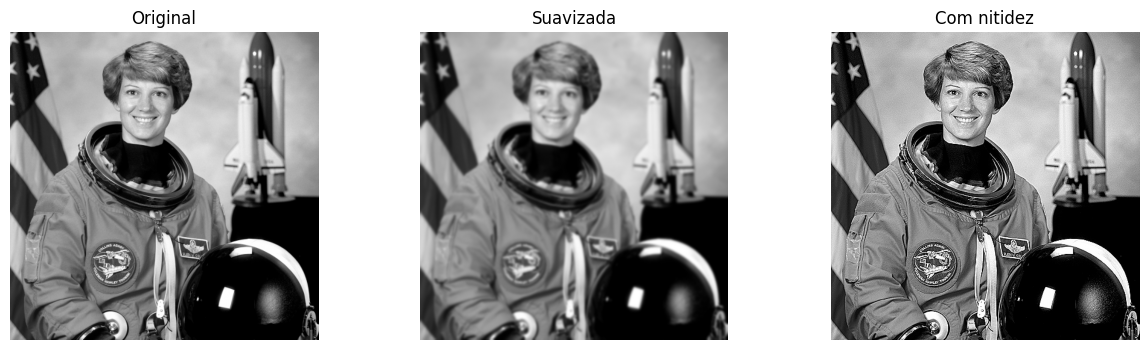

In [8]:
imagem_suave = cv2.GaussianBlur(imagem_gray, (9, 9), 0)

kernel_nitidez = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
])

imagem_nitida = cv2.filter2D(imagem_gray, -1, kernel_nitidez)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].imshow(imagem_gray, cmap="gray")
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(imagem_suave, cmap="gray")
axs[1].set_title("Suavizada")
axs[1].axis("off")

axs[2].imshow(imagem_nitida, cmap="gray")
axs[2].set_title("Com nitidez")
axs[2].axis("off")

plt.show()

## Bloco 8 — Detecção de bordas

Bordas são mudanças fortes de intensidade.

Bordas = regioes de grandes derivadas ou tendencias matematicas.

O algoritmo Canny é uma técnica clássica para destacar contornos.

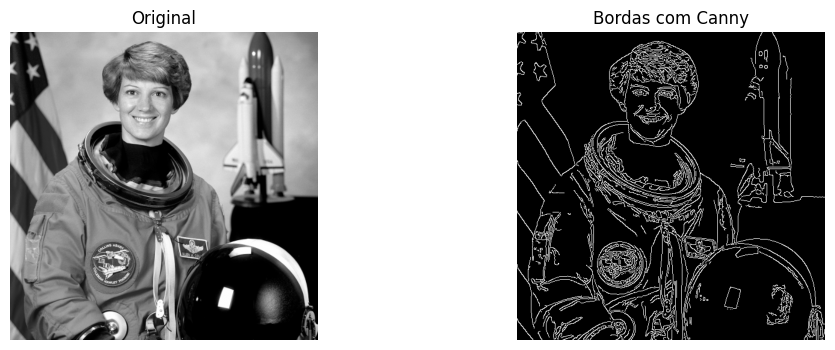

In [9]:
bordas = cv2.Canny(imagem_gray, threshold1=80, threshold2=160)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].imshow(imagem_gray, cmap="gray")
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(bordas, cmap="gray")
axs[1].set_title("Bordas com Canny")
axs[1].axis("off")

plt.show()

## Bloco 9 — Segmentação por limiar

Segmentar é separar regiões de interesse.
Operacao matematica de separacao por criterios.
Na limiarização simples:

- pixels acima do limiar viram branco;
- pixels abaixo viram preto.

Limiar manual: 120
Limiar automático de Otsu: 100.0


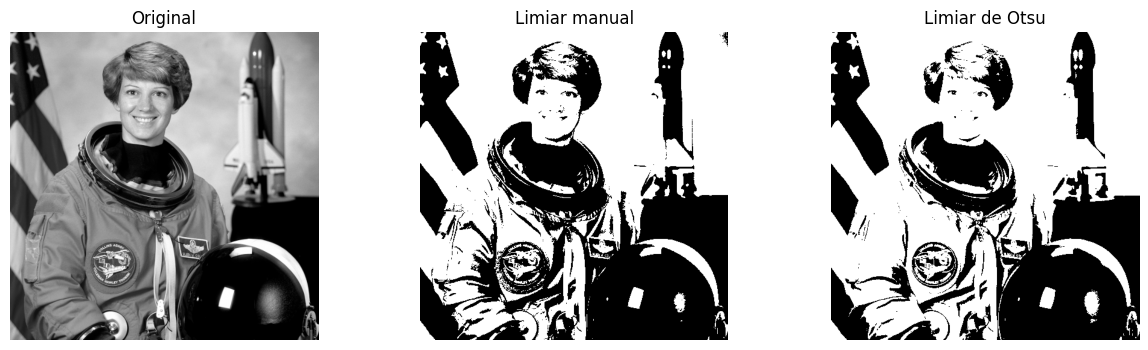

In [10]:
limiar = 120
_, imagem_binaria = cv2.threshold(imagem_gray, limiar, 255, cv2.THRESH_BINARY)

valor_otsu, imagem_otsu = cv2.threshold(
    imagem_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Limiar manual:", limiar)
print("Limiar automático de Otsu:", valor_otsu)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].imshow(imagem_gray, cmap="gray")
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(imagem_binaria, cmap="gray")
axs[1].set_title("Limiar manual")
axs[1].axis("off")

axs[2].imshow(imagem_otsu, cmap="gray")
axs[2].set_title("Limiar de Otsu")
axs[2].axis("off")

plt.show()

## Notebook 1 -- Basico de visao computacional

Neste notebook:

1. imagem como matriz;
2. canais RGB;
3. tons de cinza;
4. histograma;
5. contraste;
6. filtros;
7. bordas;
8. segmentação.

No próximo notebook, aplicacao de  conceitos para detectar objetos, extrair características e treinar um modelo simples.